# Лабораторная работа №4

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor


import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor
# from py_boost import GradientBoosting
from pycaret.classification import setup as setup_cls, compare_models as compare_cls, pull as pull_cls
from pycaret.regression import setup as setup_reg, compare_models as compare_reg, pull as pull_reg

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [2]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25,67,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15,54,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17,60,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24,92,0.99114,3.27,0.50,11.2,6,0
4894,6.6,0.32,0.36,8.0,0.047,57,168,0.99490,3.15,0.46,9.6,5,0
4895,6.5,0.24,0.19,1.2,0.041,30,111,0.99254,2.99,0.46,9.4,6,0
4896,5.5,0.29,0.30,1.1,0.022,20,110,0.98869,3.34,0.38,12.8,7,0


In [3]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6021 non-null   float64
 1   volatile acidity      6021 non-null   float64
 2   citric acid           6021 non-null   float64
 3   residual sugar        6021 non-null   float64
 4   chlorides             6021 non-null   float64
 5   free sulfur dioxide   6021 non-null   int64  
 6   total sulfur dioxide  6021 non-null   int64  
 7   density               6021 non-null   float64
 8   pH                    6021 non-null   float64
 9   sulphates             6021 non-null   float64
 10  alcohol               6021 non-null   float64
 11  quality               6021 non-null   int64  
 12  type                  6021 non-null   int64  
dtypes: float64(9), int64(4)
memory usage: 658.5 KB


In [4]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176255,-1.096824,326,-1.587838,-1.573373,-1.593630
1,-1.241582,3,5,2,-1.381334,1.591635,326,-1.641325,-1.699002,-1.766179
2,-1.199341,1,5,4,-3.437056,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461729,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099711,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672465,-0.200671,2757,0.016798,0.023909,-0.055076
53936,-0.164447,1,6,2,0.957936,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745276,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530690,0.247406,2757,0.373383,0.346954,0.290021


In [5]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


### Выделеение целевого признака и предиктора, разделение на выборки

In [6]:
X_wine = df_wine.drop(columns=['type'])
y_wine = df_wine['type']
print(X_wine.shape, y_wine.shape)
print(y_wine.value_counts())

(6021, 12) (6021,)
type
0    4600
1    1421
Name: count, dtype: int64


In [7]:
X_diamonds = df_diamonds.drop(columns=["price"])
y_diamonds = df_diamonds['price']
print(X_diamonds.shape, y_diamonds.shape)
print(y_diamonds.value_counts())

(53940, 9) (53940,)
price
605      132
802      127
625      126
828      125
776      124
        ... 
8816       1
14704      1
14699      1
14698      1
9793       1
Name: count, Length: 11602, dtype: int64


### Разделение данных

In [8]:
X_temp_wine, X_test_wine, y_temp_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RNG_SEED)
X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.25, stratify=y_temp_wine, random_state=RNG_SEED)

print(X_train_wine.shape, X_val_wine.shape, X_test_wine.shape)
print(y_train_wine.shape, X_val_wine.shape, y_test_wine.shape)


(3612, 12) (1204, 12) (1205, 12)
(3612,) (1204, 12) (1205,)


In [9]:
X_temp_diamonds, X_test_diamonds, y_temp_diamonds, y_test_diamonds = train_test_split(X_diamonds, y_diamonds, test_size=0.2, random_state=RNG_SEED)
X_train_diamonds, X_val_diamonds, y_train_diamonds, y_val_diamonds = train_test_split(X_temp_diamonds, y_temp_diamonds, test_size=0.25, random_state=RNG_SEED)

print(X_train_diamonds.shape, X_val_diamonds.shape, X_test_diamonds.shape)
print(y_train_diamonds.shape, X_val_diamonds.shape, y_test_diamonds.shape)

(32364, 9) (10788, 9) (10788, 9)
(32364,) (10788, 9) (10788,)


### Балансировка

In [10]:
y_train_wine.value_counts()

type
0    2759
1     853
Name: count, dtype: int64

In [11]:
oversample = SMOTE()

X_train_bal_wine, y_train_bal_wine = oversample.fit_resample(X_train_wine, y_train_wine)
y_train_bal_wine.value_counts()

type
0    2759
1    2759
Name: count, dtype: int64

### Вспомогательные функции

In [12]:
def calculate_metrics_cls(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

def calculate_metrics_reg(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
    }

def fmt(val, metric_name):
    if 'R2' in metric_name or 'F1' in metric_name:
        prec = 2
    else:
        prec = 4
    return f"{val:.{prec}f}"


def plot_and_extract_rules(model, X_train, feature_names):
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=feature_names, class_names=['White', 'Red'], 
              filled=True, max_depth=3, fontsize=10)
    plt.title("Decision Tree Visualization")
    plt.show()
    
    from sklearn.tree import _tree
    
    tree = model.tree_
    rules = []
    
    def extract_rules(node, conditions):
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]
            
            extract_rules(tree.children_left[node], 
                         conditions + [f"{feature} <= {threshold:.2f}"])
            extract_rules(tree.children_right[node], 
                         conditions + [f"{feature} > {threshold:.2f}"])
        else:
            class_name = 'Red' if tree.value[node][0][1] > tree.value[node][0][0] else 'White'
            rules.append(f"IF {' AND '.join(conditions)} THEN {class_name}")
    
    extract_rules(0, [])
    
    for rule in rules:
        print(f"  {rule}")

In [13]:
base_cls_models = [
    ('rf', RandomForestClassifier(random_state=RNG_SEED)),
    ('xgb', xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss')),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]

base_reg_models = [
    ('rf', RandomForestRegressor(random_state=RNG_SEED)),
    ('xgb', xgb.XGBRegressor(random_state=RNG_SEED)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
]

cls_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RNG_SEED),
    'Bagging': BaggingClassifier(random_state=RNG_SEED),
    'RandomForest': RandomForestClassifier(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingClassifier(random_state=RNG_SEED),
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', random_state=RNG_SEED), 
    'XGBoost': xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RNG_SEED, verbose=0),
    'Stacking': StackingClassifier(
        estimators=base_cls_models,
        final_estimator=LogisticRegression(multi_class='multinomial', max_iter=1000), 
        cv=5
    )
}

reg_models = {
    'DecisionTree': DecisionTreeRegressor(random_state=RNG_SEED),
    'Bagging': BaggingRegressor(random_state=RNG_SEED),
    'RandomForest': RandomForestRegressor(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingRegressor(random_state=RNG_SEED),
    'AdaBoost': AdaBoostRegressor(random_state=RNG_SEED),
    'XGBoost': xgb.XGBRegressor(random_state=RNG_SEED),
    'LightGBM': lgb.LGBMRegressor(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RNG_SEED, verbose=0),
    'Stacking': StackingRegressor(
        estimators=base_reg_models,
        final_estimator=Ridge(),
        cv=5
    )
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_diamonds = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

cls_results_wine = []
reg_results_diamonds = []

In [14]:
def train_evaluate_loop(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list):
    if task_type == 'Classification':
        scorers = {
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'F1': 'f1_weighted'
        }
    else:
        scorers = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }

    for name, model in models_dict.items():
        print(f"\n{task_type}: {name}")

        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        metrics_train = metrics_func(y_train, y_pred_train)
        metrics_test = metrics_func(y_test, y_pred_test)
        
        row = {'Algorithm': name}
        for k in metrics_train.keys():
            row[('Train Data', k)] = fmt(metrics_train[k], k)
            row[('Test Data', k)] = fmt(metrics_test[k], k)
            
        for metric_name, scorer_name in scorers.items():
            scores = cv_res[f'test_{metric_name}']
            mean_v, std_v = abs(np.mean(scores)), abs(np.std(scores))
            
            if 'R2' in metric_name or 'F1' in metric_name:
                row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.2f} ± {std_v:.2f}"
            else:
                row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.4f} ± {std_v:.4f}"
            
        res_list.append(row)

        if task_type == 'Classification':
            print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
            RocCurveDisplay.from_estimator(model, X_test, y_test)
            plt.title(f'ROC Curve - {name}')
            plt.show()
        
        print(f"    Train Metrics: { {k: fmt(metrics_train[k], k) for k in metrics_train} }")
        print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
        
        if name == 'DecisionTree' and task_type == 'Classification':
            plot_and_extract_rules(model, X_train, X_train.columns)


Classification: DecisionTree
    Confusion Matrix:
 [[913   8]
 [ 11 273]]


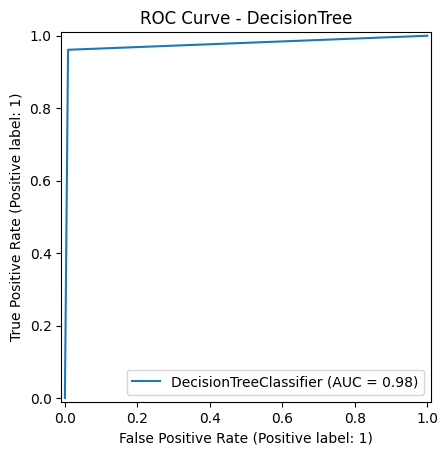

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9842', 'Precision': '0.9842', 'Recall': '0.9842', 'F1': '0.98'}


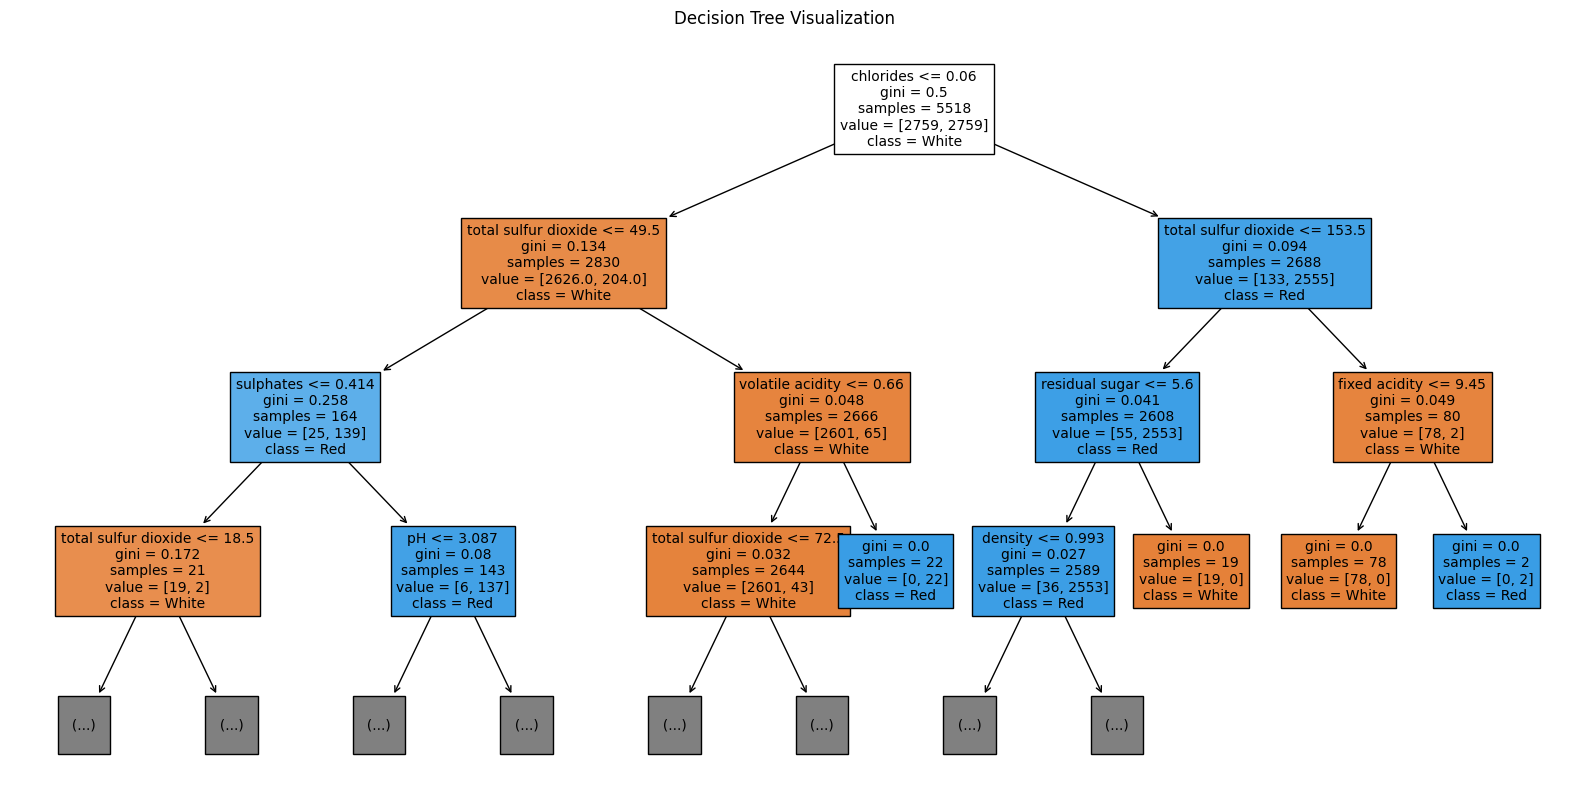

  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates <= 0.41 AND total sulfur dioxide <= 18.50 THEN Red
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates <= 0.41 AND total sulfur dioxide > 18.50 THEN White
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates > 0.41 AND pH <= 3.09 AND fixed acidity <= 10.40 THEN White
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates > 0.41 AND pH <= 3.09 AND fixed acidity > 10.40 THEN Red
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates > 0.41 AND pH > 3.09 AND residual sugar <= 1.33 AND quality <= 5.50 THEN White
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates > 0.41 AND pH > 3.09 AND residual sugar <= 1.33 AND quality > 5.50 THEN Red
  IF chlorides <= 0.06 AND total sulfur dioxide <= 49.50 AND sulphates > 0.41 AND pH > 3.09 AND residual sugar > 1.33 THEN Red
  IF chlorides <= 0.06 AND total sulfur dioxide > 49.50 AND volatile aci

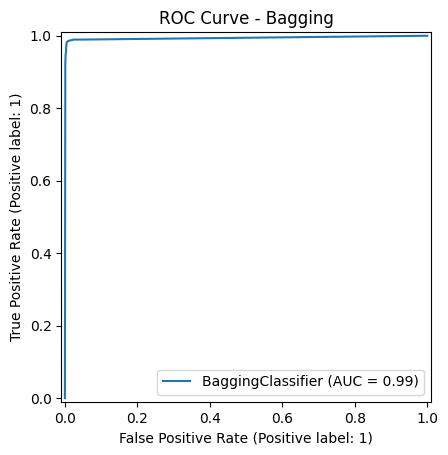

    Train Metrics: {'Accuracy': '0.9995', 'Precision': '0.9995', 'Recall': '0.9995', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9892', 'Precision': '0.9892', 'Recall': '0.9892', 'F1': '0.99'}

Classification: RandomForest
    Confusion Matrix:
 [[921   0]
 [  4 280]]


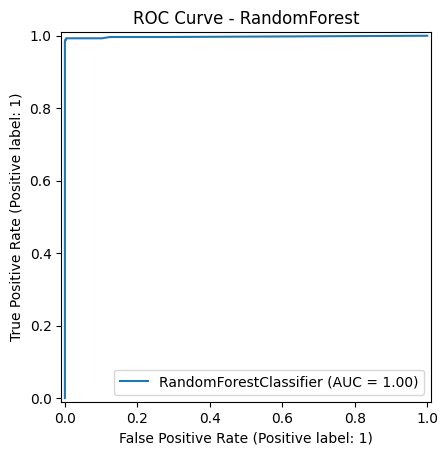

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}

Classification: GradientBoosting
    Confusion Matrix:
 [[919   2]
 [  3 281]]


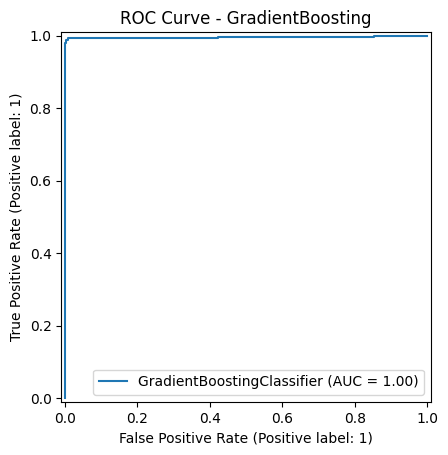

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9959', 'Precision': '0.9958', 'Recall': '0.9959', 'F1': '1.00'}

Classification: AdaBoost
    Confusion Matrix:
 [[918   3]
 [  5 279]]


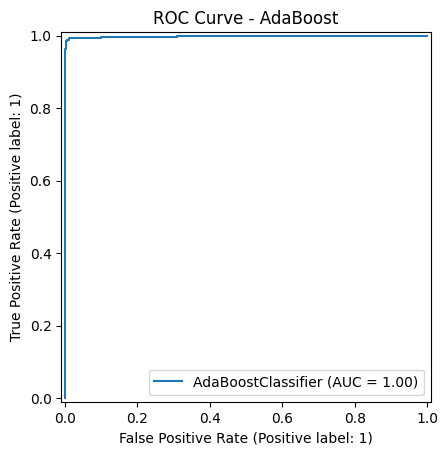

    Train Metrics: {'Accuracy': '0.9987', 'Precision': '0.9987', 'Recall': '0.9987', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9934', 'Precision': '0.9934', 'Recall': '0.9934', 'F1': '0.99'}

Classification: XGBoost
    Confusion Matrix:
 [[921   0]
 [  3 281]]


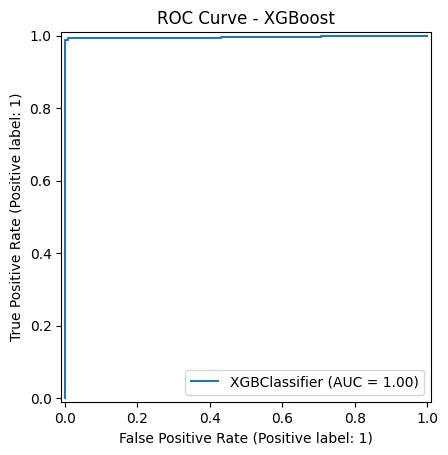

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9975', 'Precision': '0.9975', 'Recall': '0.9975', 'F1': '1.00'}

Classification: LightGBM


  File "c:\Users\danii\Desktop\git\master\mlbd\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


    Confusion Matrix:
 [[919   2]
 [  4 280]]


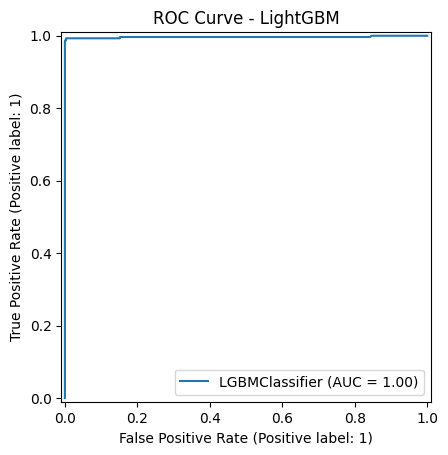

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9950', 'Precision': '0.9950', 'Recall': '0.9950', 'F1': '1.00'}

Classification: CatBoost
    Confusion Matrix:
 [[919   2]
 [  3 281]]


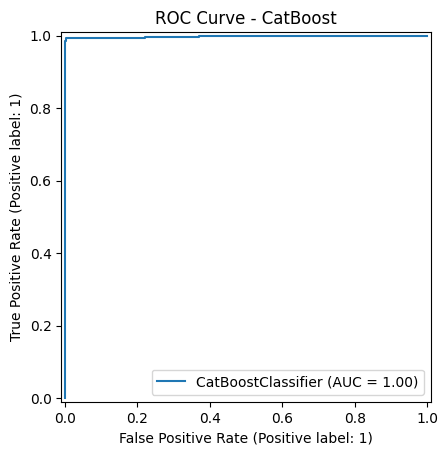

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9959', 'Precision': '0.9958', 'Recall': '0.9959', 'F1': '1.00'}

Classification: Stacking
    Confusion Matrix:
 [[921   0]
 [  4 280]]


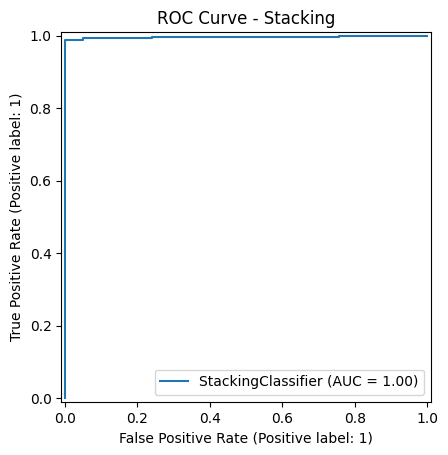

    Train Metrics: {'Accuracy': '0.9998', 'Precision': '0.9998', 'Recall': '0.9998', 'F1': '1.00'}
    Test Metrics: {'Accuracy': '0.9967', 'Precision': '0.9967', 'Recall': '0.9967', 'F1': '1.00'}


In [15]:
train_evaluate_loop(cls_models, X_train_bal_wine, y_train_bal_wine, X_val_wine, y_val_wine, X_test_wine, y_test_wine, cv_wine, 'Classification', calculate_metrics_cls, cls_results_wine)

In [16]:
train_evaluate_loop(reg_models, X_train_diamonds, y_train_diamonds, X_val_diamonds, y_val_diamonds, X_test_diamonds, y_test_diamonds, cv_diamonds, 'Regression', calculate_metrics_reg, reg_results_diamonds)


Regression: DecisionTree
    Train Metrics: {'R2': '1.00', 'RMSE': '6.8985', 'MAE': '0.3618', 'MSE': '47.5890'}
    Test Metrics: {'R2': '0.96', 'RMSE': '757.3818', 'MAE': '369.3796', 'MSE': '573627.1410'}

Regression: Bagging
    Train Metrics: {'R2': '1.00', 'RMSE': '240.5994', 'MAE': '113.8524', 'MSE': '57888.0756'}
    Test Metrics: {'R2': '0.98', 'RMSE': '574.8184', 'MAE': '287.9027', 'MSE': '330416.1764'}

Regression: RandomForest
    Train Metrics: {'R2': '1.00', 'RMSE': '204.1601', 'MAE': '101.3997', 'MSE': '41681.3667'}
    Test Metrics: {'R2': '0.98', 'RMSE': '551.1310', 'MAE': '273.1333', 'MSE': '303745.3730'}

Regression: GradientBoosting
    Train Metrics: {'R2': '0.98', 'RMSE': '593.8963', 'MAE': '335.2126', 'MSE': '352712.8376'}
    Test Metrics: {'R2': '0.98', 'RMSE': '605.5833', 'MAE': '337.9039', 'MSE': '366731.1416'}

Regression: AdaBoost
    Train Metrics: {'R2': '0.92', 'RMSE': '1116.2265', 'MAE': '845.5645', 'MSE': '1245961.6752'}
    Test Metrics: {'R2': '0.92',

In [17]:
reg_results_diamonds

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.96',
  ('Train Data', 'RMSE'): '6.8985',
  ('Test Data', 'RMSE'): '757.3818',
  ('Train Data', 'MAE'): '0.3618',
  ('Test Data', 'MAE'): '369.3796',
  ('Train Data', 'MSE'): '47.5890',
  ('Test Data', 'MSE'): '573627.1410',
  ('K-Fold CV', 'R2 (mean±std)'): '0.96 ± 0.00',
  ('K-Fold CV', 'RMSE (mean±std)'): '763.3514 ± 30.0703',
  ('K-Fold CV', 'MAE (mean±std)'): '380.6640 ± 11.5696',
  ('K-Fold CV', 'MSE (mean±std)'): '583609.5924 ± 44874.5960'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'R2'): '1.00',
  ('Test Data', 'R2'): '0.98',
  ('Train Data', 'RMSE'): '240.5994',
  ('Test Data', 'RMSE'): '574.8184',
  ('Train Data', 'MAE'): '113.8524',
  ('Test Data', 'MAE'): '287.9027',
  ('Train Data', 'MSE'): '57888.0756',
  ('Test Data', 'MSE'): '330416.1764',
  ('K-Fold CV', 'R2 (mean±std)'): '0.98 ± 0.00',
  ('K-Fold CV', 'RMSE (mean±std)'): '586.8788 ± 15.3392',
  ('K-Fold CV', 'MAE (mean±std)'): '2

In [18]:
cls_results_wine

[{'Algorithm': 'DecisionTree',
  ('Train Data', 'Accuracy'): '0.9998',
  ('Test Data', 'Accuracy'): '0.9842',
  ('Train Data', 'Precision'): '0.9998',
  ('Test Data', 'Precision'): '0.9842',
  ('Train Data', 'Recall'): '0.9998',
  ('Test Data', 'Recall'): '0.9842',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.98',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9877 ± 0.0035',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9877 ± 0.0035',
  ('K-Fold CV', 'Recall (mean±std)'): '0.9877 ± 0.0035',
  ('K-Fold CV', 'F1 (mean±std)'): '0.99 ± 0.00'},
 {'Algorithm': 'Bagging',
  ('Train Data', 'Accuracy'): '0.9995',
  ('Test Data', 'Accuracy'): '0.9892',
  ('Train Data', 'Precision'): '0.9995',
  ('Test Data', 'Precision'): '0.9892',
  ('Train Data', 'Recall'): '0.9995',
  ('Test Data', 'Recall'): '0.9892',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('K-Fold CV', 'Accuracy (mean±std)'): '0.9937 ± 0.0019',
  ('K-Fold CV', 'Precision (mean±std)'): '0.9937 ± 0.0019',
  

In [19]:
CLS_HYPERPARAMS = {
    'DecisionTree': {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Bagging': {'n_estimators': [50, 100], 'max_samples': [0.7, 1.0], 'bootstrap': [True, False]},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'max_depth': [-1, 5], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]},
    'CatBoost': {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
}

REG_HYPERPARAMS = {
    'DecisionTree': {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Bagging': {'n_estimators': [50, 100], 'max_samples': [0.7, 1.0], 'bootstrap': [True, False]},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'GradientBoosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'max_depth': [-1, 5], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]},
    'CatBoost': {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
}

In [20]:
def run_optuna(model_name, model, X_train, y_train, cv, task_type='classification', n_trials=10):
    print(f"        Optuna ({n_trials} trials)...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    def objective(trial):
        params = {}
        for param, values in hyperparams.items():
            if param in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 
                         'iterations', 'depth', 'num_leaves']:
                if param == 'max_depth' and None in values:
                    params[param] = trial.suggest_categorical(param, values)
                else:
                    params[param] = trial.suggest_int(param, min(values), max(values))
            elif param in ['learning_rate']:
                params[param] = trial.suggest_float(param, min(values), max(values), log=True)
            else:
                params[param] = trial.suggest_categorical(param, values)
        
        model.set_params(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RNG_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    
    print(f"  best={study.best_value:.4f}")
    return study.best_value, study.best_params

def run_grid_search(model_name, model, X_train, y_train, cv, task_type='classification'):
    print(f"        Grid Search...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    total = 1
    for v in hyperparams.values():
        total *= len(v)
    print(f"({total} комбинаций, берем 20)...", end=' ')
    
    search = RandomizedSearchCV(
        model, hyperparams, n_iter=min(20, total), cv=cv,
        scoring=scoring, n_jobs=-1, random_state=RNG_SEED
    )
    search.fit(X_train, y_train)
    
    print(f"  best={search.best_score_:.4f}")
    return search.best_score_, search.best_params_

def run_random_search(model_name, model, X_train, y_train, cv, task_type='classification', n_iter=10):
    print(f"        Random Search ({n_iter} итераций)...", end=' ')
    
    if task_type == 'classification':
        hyperparams = CLS_HYPERPARAMS.get(model_name, {})
        scoring = 'f1_weighted'
    else:
        hyperparams = REG_HYPERPARAMS.get(model_name, {})
        scoring = 'r2'
    
    search = RandomizedSearchCV(
        model, hyperparams, n_iter=n_iter, cv=cv,
        scoring=scoring, n_jobs=-1, random_state=RNG_SEED
    )
    search.fit(X_train, y_train)
    
    print(f"  best={search.best_score_:.4f}")
    return search.best_score_, search.best_params_

In [21]:
def train_evaluate_loop_optimized(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list):
    if task_type == 'Classification':
        scorers = {
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'F1': 'f1_weighted'
        }
    else:
        scorers = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }

    strategies = [
        ('_optuna', 'Optuna', run_optuna),
        ('_random', 'Random', run_random_search),
        ('_grid', 'Grid', run_grid_search)
    ]

    for name, base_model in models_dict.items():
        
        for suffix, strategy_name, opt_func in strategies:
            current_model_name = f"{name}{suffix}"
            print(f"\n{task_type}: {current_model_name} [{strategy_name}]")

            model = clone(base_model)

            if opt_func:
                try:
                    best_score, best_params = opt_func(name, model, X_train, y_train, cv, task_type)
                    
                    model.set_params(**best_params)
                    print(f"    Applied best params for {current_model_name}")
                except Exception as e:
                    print(f"    Optimization failed for {current_model_name}: {e}")
            
            cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scorers, n_jobs=-1)
            
            model.fit(X_train, y_train)
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)
            
            metrics_train = metrics_func(y_train, y_pred_train)
            metrics_test = metrics_func(y_test, y_pred_test)
            
            row = {'Algorithm': current_model_name}
            for k in metrics_train.keys():
                row[('Train Data', k)] = fmt(metrics_train[k], k)
                row[('Test Data', k)] = fmt(metrics_test[k], k)
                
            for metric_name, scorer_name in scorers.items():
                scores = cv_res[f'test_{metric_name}']
                mean_v, std_v = abs(np.mean(scores)), abs(np.std(scores))
                
                if 'R2' in metric_name or 'F1' in metric_name:
                    row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.2f} ± {std_v:.2f}"
                else:
                    row[('K-Fold CV', f'{metric_name} (mean±std)')] = f"{mean_v:.4f} ± {std_v:.4f}"
                
            res_list.append(row)

            if task_type == 'Classification':
                print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
                try:
                    RocCurveDisplay.from_estimator(model, X_test, y_test)
                    plt.title(f'ROC Curve - {current_model_name}')
                    plt.show()
                except:
                    pass
            
            print(f"    Train Metrics: { {k: fmt(metrics_train[k], k) for k in metrics_train} }")
            print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
            
            if 'DecisionTree' in current_model_name and task_type == 'Classification':
                plot_and_extract_rules(model, X_train, X_train.columns)

In [ ]:
train_evaluate_loop_optimized(
    cls_models, 
    X_train_bal_wine, y_train_bal_wine, 
    X_val_wine, y_val_wine, 
    X_test_wine, y_test_wine, 
    cv_wine, 
    'Classification', 
    calculate_metrics_cls, 
    cls_results_wine
)

In [ ]:
train_evaluate_loop_optimized(
    reg_models, 
    X_train_diamonds, y_train_diamonds, 
    X_val_diamonds, y_val_diamonds, 
    X_test_diamonds, y_test_diamonds, 
    cv_diamonds, 
    'Regression', 
    calculate_metrics_reg, 
    reg_results_diamonds
)

In [30]:
print(" Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...")
setup_cls(data=pd.concat([X_train_bal_wine, y_train_bal_wine], axis=1), 
          target='type', train_size=0.6, fold=5, verbose=False)

best_cls_pycaret = compare_cls(sort='F1', n_select=10)
pycaret_cls_results = pull_cls()

cls_cols = [c for c in ['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'Precision', 'F1', 'F1 Score', 'Kappa'] 
            if c in pycaret_cls_results.columns]
display(pycaret_cls_results[cls_cols])

 Запуск PyCaret для задачи КЛАССИФИКАЦИИ (Wine)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9985,0.9992,0.9988,0.9982,0.9985,0.9970,0.9970,0.0780
lda,Linear Discriminant Analysis,0.9982,0.9996,0.9976,0.9988,0.9982,0.9964,0.9964,0.0180
rf,Random Forest Classifier,0.9979,0.9996,0.9988,0.9970,0.9979,0.9958,0.9958,0.1000
catboost,CatBoost Classifier,0.9979,0.9996,0.9988,0.9970,0.9979,0.9958,0.9958,1.2960
qda,Quadratic Discriminant Analysis,0.9973,0.9998,0.9988,0.9958,0.9973,0.9946,0.9946,0.0160
ada,Ada Boost Classifier,0.9973,0.9995,0.9982,0.9964,0.9973,0.9946,0.9946,0.0800
gbc,Gradient Boosting Classifier,0.9973,0.9996,0.9982,0.9964,0.9973,0.9946,0.9946,0.1940
xgboost,Extreme Gradient Boosting,0.9973,0.9995,0.9982,0.9964,0.9973,0.9946,0.9946,0.0380
lightgbm,Light Gradient Boosting Machine,0.9964,0.9994,0.9964,0.9964,0.9964,0.9927,0.9928,0.1200
ridge,Ridge Classifier,0.9958,0.9997,0.9952,0.9964,0.9958,0.9915,0.9915,0.0140


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa
et,Extra Trees Classifier,0.9985,0.9992,0.9988,0.9982,0.9985,0.9970
lda,Linear Discriminant Analysis,0.9982,0.9996,0.9976,0.9988,0.9982,0.9964
rf,Random Forest Classifier,0.9979,0.9996,0.9988,0.9970,0.9979,0.9958
catboost,CatBoost Classifier,0.9979,0.9996,0.9988,0.9970,0.9979,0.9958
qda,Quadratic Discriminant Analysis,0.9973,0.9998,0.9988,0.9958,0.9973,0.9946
ada,Ada Boost Classifier,0.9973,0.9995,0.9982,0.9964,0.9973,0.9946
gbc,Gradient Boosting Classifier,0.9973,0.9996,0.9982,0.9964,0.9973,0.9946
xgboost,Extreme Gradient Boosting,0.9973,0.9995,0.9982,0.9964,0.9973,0.9946
lightgbm,Light Gradient Boosting Machine,0.9964,0.9994,0.9964,0.9964,0.9964,0.9927
ridge,Ridge Classifier,0.9958,0.9997,0.9952,0.9964,0.9958,0.9915


Pycaret демонстрирует очень схожие метрики с натренированными моделями

In [31]:
print("\n\n Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...")
setup_reg(data=pd.concat([X_train_diamonds, y_train_diamonds], axis=1), 
          target='price', train_size=0.8, fold=5, verbose=False)

best_reg_pycaret = compare_reg(sort='R2', n_select=10)
pycaret_reg_results = pull_reg()

reg_cols = [c for c in ['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'RMSLE'] 
            if c in pycaret_reg_results.columns]
display(pycaret_reg_results[reg_cols])



 Запуск PyCaret для задачи РЕГРЕССИИ (Diamonds)...


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,275.6895,289712.5427,537.8582,0.9820,0.1000,0.0753,2.1260
lightgbm,Light Gradient Boosting Machine,283.0780,296449.6561,544.0621,0.9815,0.1068,0.0815,0.1760
et,Extra Trees Regressor,278.4121,308027.6337,554.7289,0.9808,0.0956,0.0699,0.8020
xgboost,Extreme Gradient Boosting,284.7456,310568.1102,557.0250,0.9806,0.0981,0.0736,0.1020
rf,Random Forest Regressor,282.5615,320038.2863,565.3042,0.9801,0.0951,0.0693,1.1020
gbr,Gradient Boosting Regressor,345.9698,396309.4201,629.3702,0.9753,0.1505,0.1081,0.4940
knn,K Neighbors Regressor,411.4867,590832.2769,768.3379,0.9632,0.1528,0.1177,0.0840
dt,Decision Tree Regressor,386.5599,601544.7986,775.2258,0.9625,0.1317,0.0933,0.0500
ada,AdaBoost Regressor,862.3662,1251776.9642,1118.2819,0.9219,0.4288,0.4525,0.3140
lr,Linear Regression,805.8995,1458870.8921,1207.4130,0.9090,0.6550,0.4418,0.0180


,Model,MAE,MSE,RMSE,R2,RMSLE
catboost,CatBoost Regressor,275.6895,2.897125e+05,537.8582,0.9820,0.1000
lightgbm,Light Gradient Boosting Machine,283.0780,2.964497e+05,544.0621,0.9815,0.1068
et,Extra Trees Regressor,278.4121,3.080276e+05,554.7289,0.9808,0.0956
xgboost,Extreme Gradient Boosting,284.7456,3.105681e+05,557.0250,0.9806,0.0981
rf,Random Forest Regressor,282.5615,3.200383e+05,565.3042,0.9801,0.0951
gbr,Gradient Boosting Regressor,345.9698,3.963094e+05,629.3702,0.9753,0.1505
knn,K Neighbors Regressor,411.4867,5.908323e+05,768.3379,0.9632,0.1528
dt,Decision Tree Regressor,386.5599,6.015448e+05,775.2258,0.9625,0.1317
ada,AdaBoost Regressor,862.3662,1.251777e+06,1118.2819,0.9219,0.4288
lr,Linear Regression,805.8995,1.458871e+06,1207.4130,0.9090,0.6550


Pycaret демонстрирует очень схожие метрики с натренированными моделями

In [32]:
def build_and_display_tables(results_list, task_name, metrics_order):
    print(f"{task_name}")
    df = pd.DataFrame(results_list).set_index('Algorithm')
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    cols_1 = [c for c in df.columns if c[0] in ['Train Data', 'Test Data']]
    cols_1_sorted = sorted(cols_1, key=lambda c: (0 if c[0]=='Train Data' else 1, metrics_order.index(c[1])))
    table_1 = df[cols_1_sorted]
    display(table_1)
    
    cols_2 = [c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]
    cols_2_renamed = [('Метод hold-out', c[1]) if c[0] == 'Test Data' else c for c in cols_2]
    cols_2_sorted = sorted(cols_2_renamed, key=lambda c: (
        0 if c[0]=='Метод hold-out' else 1, 
        metrics_order.index(c[1].split(' (')[0])
    ))
    table_2 = df[[c for c in df.columns if c[0] in ['Test Data', 'K-Fold CV']]].copy()
    table_2.columns = pd.MultiIndex.from_tuples(cols_2_sorted)
    display(table_2)
    
    return table_1, table_2

cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
reg_metrics = ['R2', 'RMSE', 'MAE', 'MSE']

tbl1_cls, tbl2_cls = build_and_display_tables(cls_results_wine, "Классификация (Wine)", cls_metrics)
tbl1_reg, tbl2_reg = build_and_display_tables(reg_results_diamonds, "Регрессия (Diamonds)", reg_metrics)

Классификация (Wine)


Train Data                         Test Data            \
                   Accuracy Precision  Recall    F1  Accuracy Precision   
Algorithm                                                                 
DecisionTree         0.9998    0.9998  0.9998  1.00    0.9842    0.9842   
Bagging              0.9995    0.9995  0.9995  1.00    0.9892    0.9892   
RandomForest         0.9998    0.9998  0.9998  1.00    0.9967    0.9967   
GradientBoosting     0.9998    0.9998  0.9998  1.00    0.9959    0.9958   
AdaBoost             0.9987    0.9987  0.9987  1.00    0.9934    0.9934   
XGBoost              0.9998    0.9998  0.9998  1.00    0.9975    0.9975   
LightGBM             0.9998    0.9998  0.9998  1.00    0.9950    0.9950   
CatBoost             0.9998    0.9998  0.9998  1.00    0.9959    0.9958   
Stacking             0.9998    0.9998  0.9998  1.00    0.9967    0.9967   

                                
                  Recall    F1  
Algorithm                       
DecisionTree      0.9842  0.98  
Bagging           0.9892  0.99  
RandomForest      0.9967  1.00  
GradientBoosting  0.9959  1.00  
AdaBoost          0.9934  0.99  
XGBoost           0.9975  1.00  
LightGBM          0.9950  1.00  
CatBoost          0.9959  1.00  
Stacking          0.9967  1.00

Метод hold-out                                   K-Fold CV  \
                       Accuracy Precision  Recall    F1 Accuracy (mean±std)   
Algorithm                                                                     
DecisionTree             0.9842    0.9842  0.9842  0.98     0.9877 ± 0.0035   
Bagging                  0.9892    0.9892  0.9892  0.99     0.9937 ± 0.0019   
RandomForest             0.9967    0.9967  0.9967  1.00     0.9975 ± 0.0016   
GradientBoosting         0.9959    0.9958  0.9959  1.00     0.9966 ± 0.0022   
AdaBoost                 0.9934    0.9934  0.9934  0.99     0.9953 ± 0.0011   
XGBoost                  0.9975    0.9975  0.9975  1.00     0.9969 ± 0.0009   
LightGBM                 0.9950    0.9950  0.9950  1.00     0.9967 ± 0.0012   
CatBoost                 0.9959    0.9958  0.9959  1.00     0.9975 ± 0.0011   
Stacking                 0.9967    0.9967  0.9967  1.00     0.9971 ± 0.0015   

                                                                       
                 Precision (mean±std) Recall (mean±std) F1 (mean±std)  
Algorithm                                                              
DecisionTree          0.9877 ± 0.0035   0.9877 ± 0.0035   0.99 ± 0.00  
Bagging               0.9937 ± 0.0019   0.9937 ± 0.0019   0.99 ± 0.00  
RandomForest          0.9975 ± 0.0016   0.9975 ± 0.0016   1.00 ± 0.00  
GradientBoosting      0.9966 ± 0.0022   0.9966 ± 0.0022   1.00 ± 0.00  
AdaBoost              0.9953 ± 0.0010   0.9953 ± 0.0011   1.00 ± 0.00  
XGBoost               0.9969 ± 0.0009   0.9969 ± 0.0009   1.00 ± 0.00  
LightGBM              0.9967 ± 0.0012   0.9967 ± 0.0012   1.00 ± 0.00  
CatBoost              0.9975 ± 0.0011   0.9975 ± 0.0011   1.00 ± 0.00  
Stacking              0.9971 ± 0.0014   0.9971 ± 0.0015   1.00 ± 0.00

Регрессия (Diamonds)


Train Data                                    Test Data  \
                         R2       RMSE       MAE           MSE        R2   
Algorithm                                                                  
DecisionTree           1.00     6.8985    0.3618       47.5890      0.96   
Bagging                1.00   240.5994  113.8524    57888.0756      0.98   
RandomForest           1.00   204.1601  101.3997    41681.3667      0.98   
GradientBoosting       0.98   593.8963  335.2126   352712.8376      0.98   
AdaBoost               0.92  1116.2265  845.5645  1245961.6752      0.92   
XGBoost                0.99   364.3735  209.5104   132768.0757      0.98   
LightGBM               0.99   459.9733  255.5454   211575.3944      0.98   
CatBoost               0.99   414.1394  233.4237   171511.4598      0.98   
Stacking               1.00   279.3950  154.5618    78061.5730      0.98   

                                                     
                       RMSE       MAE           MSE  
Algorithm                                            
DecisionTree       757.3818  369.3796   573627.1410  
Bagging            574.8184  287.9027   330416.1764  
RandomForest       551.1310  273.1333   303745.3730  
GradientBoosting   605.5833  337.9039   366731.1416  
AdaBoost          1131.6233  855.3261  1280571.2541  
XGBoost            538.4275  274.0915   289904.1666  
LightGBM           540.5021  280.0365   292142.5190  
CatBoost           529.9435  269.6883   280840.0622  
Stacking           524.9272  261.3267   275548.5307

Метод hold-out                                     \
                             R2       RMSE       MAE           MSE   
Algorithm                                                            
DecisionTree               0.96   757.3818  369.3796   573627.1410   
Bagging                    0.98   574.8184  287.9027   330416.1764   
RandomForest               0.98   551.1310  273.1333   303745.3730   
GradientBoosting           0.98   605.5833  337.9039   366731.1416   
AdaBoost                   0.92  1131.6233  855.3261  1280571.2541   
XGBoost                    0.98   538.4275  274.0915   289904.1666   
LightGBM                   0.98   540.5021  280.0365   292142.5190   
CatBoost                   0.98   529.9435  269.6883   280840.0622   
Stacking                   0.98   524.9272  261.3267   275548.5307   

                     K-Fold CV                                           \
                 R2 (mean±std)      RMSE (mean±std)      MAE (mean±std)   
Algorithm                                                                 
DecisionTree       0.96 ± 0.00   763.3514 ± 30.0703  380.6640 ± 11.5696   
Bagging            0.98 ± 0.00   586.8788 ± 15.3392   295.4849 ± 8.1897   
RandomForest       0.98 ± 0.00   560.5354 ± 12.9975   280.2774 ± 8.7012   
GradientBoosting   0.98 ± 0.00   625.9003 ± 12.6214   345.4352 ± 6.6810   
AdaBoost           0.92 ± 0.00  1136.3287 ± 28.9625  877.6011 ± 22.1348   
XGBoost            0.98 ± 0.00   558.5615 ± 20.7874   284.0494 ± 8.0942   
LightGBM           0.98 ± 0.00   543.9703 ± 16.1062   284.2860 ± 7.4539   
CatBoost           0.98 ± 0.00   532.0124 ± 13.7744   273.8969 ± 5.6708   
Stacking           0.98 ± 0.00   538.8312 ± 14.3666   269.8929 ± 7.5514   

                                             
                             MSE (mean±std)  
Algorithm                                    
DecisionTree       583609.5924 ± 44874.5960  
Bagging            344662.0399 ± 17905.0110  
RandomForest       314368.9176 ± 14453.9224  
GradientBoosting   391910.5278 ± 15721.8653  
AdaBoost          1292081.6718 ± 65788.9058  
XGBoost            312423.0351 ± 23192.7865  
LightGBM           296163.1234 ± 17503.0143  
CatBoost           283226.9274 ± 14669.2709  
Stacking           290545.4498 ± 15455.5009

## Вывод

В ходе выполнения лабораторной работы №4 решены задачи **бинарной классификации** (тип вина) и **регрессии** (цена бриллианта).

### Оптимизация гиперпараметров

Применены три метода: **Optuna**, **RandomizedSearchCV**, **GridSearchCV**. Все модели изначально показали высокие результаты, поэтому оптимизация не дала значительного прироста качества, но увеличила время вычислений.

### Классификация (Wine)

**Лучшие модели:** `RandomForest` и `LightGBM` (F1-score = 1.00)

#### Интерпретация правил

**Уровень 1 - Главное ветвление:**
- `chlorides <= 0.38` → **белое вино** (основное правило)
- `chlorides > 0.38` → **красное вино**

**Уровень 2 - Уточняющие признаки для белого вина (chlorides <= 0.38):**
- `total sulfur dioxide` (общий диоксид серы)
- `alcohol` (содержание алкоголя)
- `volatile acidity` (летучая кислотность)
- `pH`

**Уровень 2 - Уточняющие признаки для красного вина (chlorides > 0.38):**
- `total sulfur dioxide`
- `residual sugar` (остаточный сахар)
- `density` (плотность)
- `fixed acidity` (фиксированная кислотность)

**Ключевые выводы по признакам:**
1. **Хлориды** — самый важный признак, полностью разделяющий классы
2. При низких хлоридах решение зависит от диоксида серы и алкоголя
3. При высоких хлоридах важны плотность и остаточный сахар

### Регрессия (Diamonds)

**Лучшие модели:** `StackingRegressor`, `CatBoost`, `XGBoost` (R² ≈ 0.98)

**Интерпретация:**
- **carat** (вес) — самый сильный предиктор цены
- **cut, color, clarity** — значимо влияют на стоимость

### Сравнение с PyCaret

Результаты ручного подбора совпадают с автоматизированным пайплайном, что подтверждает корректность эксперимента.

Как итог можно сказать, что **ансамблевые методы** и **градиентный бустинг** превосходят одиночные модели
